# 1.Load data

- 데이터 경로와 형식을 파악하고, Train, test, gt files로 분할하자.

In [34]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

car_dir = Path("data/real3dad/toffees/")

train_files = sorted((car_dir / "train").glob("*.pcd"))
test_files = sorted((car_dir / "test").glob("*.pcd"))
gt_files = sorted((car_dir / "gt").glob("*.txt"))

print("train:", len(train_files))
print("test :", len(test_files))
print("gt   :", len(gt_files))
print("첫 번째 test 파일:", test_files[0].name)

train: 4
test : 100
gt   : 50
첫 번째 test 파일: 258_good.pcd


# 2. Checking Pcd

- PCD파일은 header부분과 (x1, y1, z1)이 하나의 행으로 행렬로 구성된 실제 데이터 부분으로 나누어진다.
- Pcd 파일을 실제 데이터 부분 전까지 읽고 출력하는 코드를 작성하자.

In [ ]:
sample_path = car_dir / "test" / "258_good.pcd"

with sample_path.open("rb") as f:
    while True:
        line = f.readline().decode("ascii").strip()
        print(line)
        if line.startswith("DATA"):
            break

FileNotFoundError: [Errno 2] No such file or directory: 'data/real3dad/toffees/test/146_good.pcd'

# 3.PCD를 numpy로 변환하는 과정

In [ ]:
def load_xyz_pcd(path):
    with Path(path).open("rb") as f:
        header = {}

        while True:
            raw = f.readline()
            if not raw:
                raise ValueError("PCD 헤더가 완전하지 않습니다.")

            line = raw.decode("ascii").strip()
            if not line or line.startswith("#"):
                continue

            key, *values = line.split()
            header[key] = values

            if key == "DATA":
                break

        # 다른 형식의 PCD를 잘못 읽지 않도록 확인
        assert header["FIELDS"] == ["x", "y", "z"]
        assert header["SIZE"] == ["4", "4", "4"]
        assert header["TYPE"] == ["F", "F", "F"]
        assert header.get("COUNT", ["1", "1", "1"]) == ["1", "1", "1"]
        assert header["DATA"] == ["binary"]

        num_points = int(header["POINTS"][0])
        values = np.frombuffer(f.read(), dtype="<f4")
        assert values.size == num_points * 3

    return values.reshape(num_points, 3)

In [ ]:
points = load_xyz_pcd(sample_path)

print("shape:", points.shape)
print("dtype:", points.dtype)
print("첫 5개 점:\n", points[:5])

shape: (90650, 3)
dtype: float32
첫 5개 점:
 [[113.511826    2.207765  218.20288  ]
 [113.44476     2.2077084 218.19727  ]
 [113.38338     2.2077615 218.20259  ]
 [113.326454    2.2079024 218.2165   ]
 [113.27271     2.208105  218.23656  ]]


In [ ]:
print("XYZ 최솟값:", points.min(axis=0))
print("XYZ 최댓값:", points.max(axis=0))
print("XYZ 중심점:", points.mean(axis=0))
print("모든 좌표가 유한한가:", np.isfinite(points).all())

XYZ 최솟값: [ 91.420784 -12.316896 214.8593  ]
XYZ 최댓값: [119.29732   12.919962 224.43977 ]
XYZ 중심점: [105.01669     -0.68611765 218.99892   ]
모든 좌표가 유한한가: True


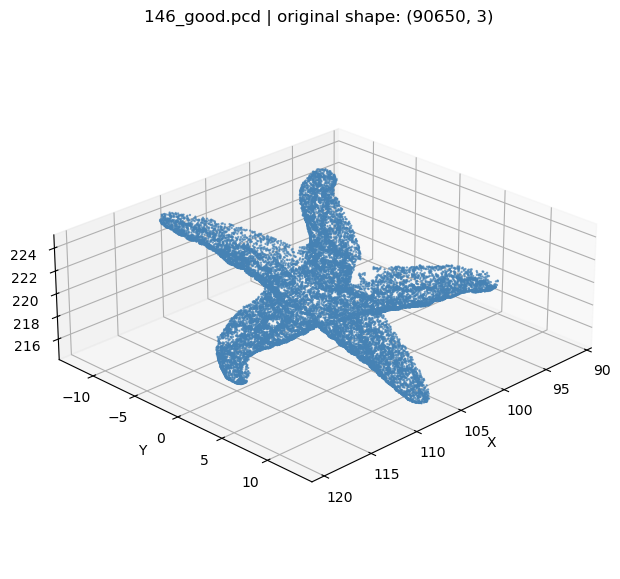

In [ ]:
rng = np.random.default_rng(42)

indices = rng.choice(
    len(points),
    size=min(20_000, len(points)),
    replace=False,
)
plot_points = points[indices]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    plot_points[:, 0],
    plot_points[:, 1],
    plot_points[:, 2],
    s=0.5,
    color="steelblue",
    alpha=0.7,
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title(f"{sample_path.name} | original shape: {points.shape}")

# XYZ의 실제 비율을 유지해 자동차 모양이 찌그러지지 않도록 설정
ax.set_box_aspect(np.maximum(np.ptp(points, axis=0), 1e-6))
ax.view_init(elev=25, azim=45)

plt.show()

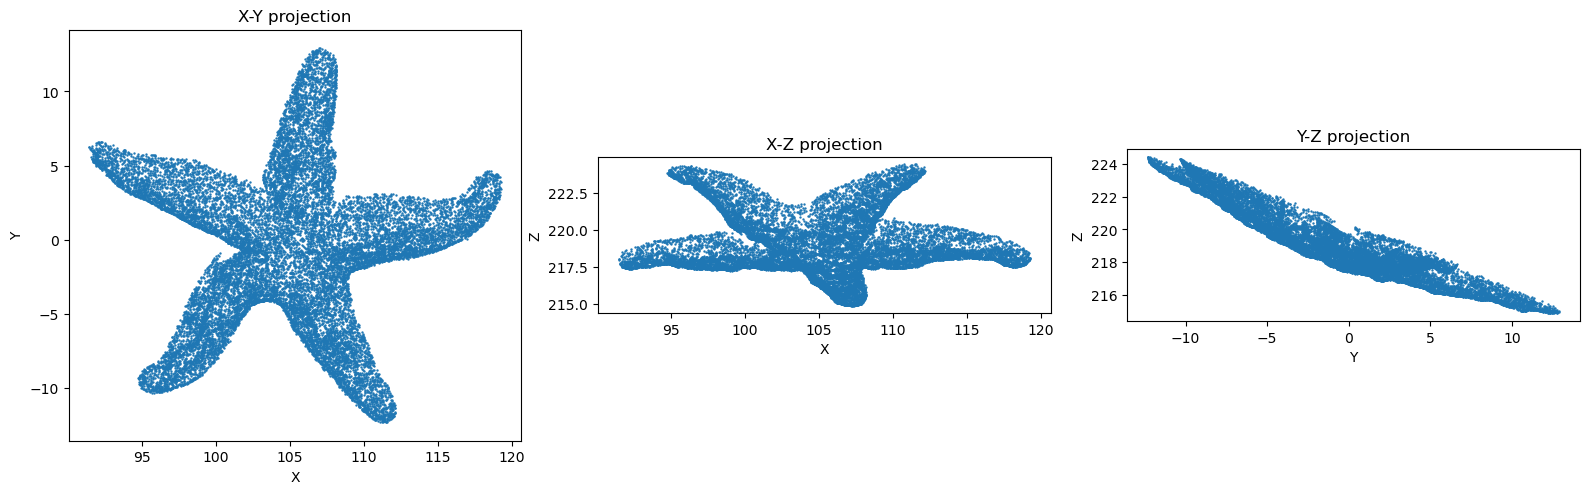

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

views = [
    (0, 1, "X", "Y"),
    (0, 2, "X", "Z"),
    (1, 2, "Y", "Z"),
]

for ax, (i, j, xlabel, ylabel) in zip(axes, views):
    ax.scatter(plot_points[:, i], plot_points[:, j], s=0.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{xlabel}-{ylabel} projection")
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

In [ ]:
gt_path = car_dir / "gt" / "442_bulge.txt"
gt = np.loadtxt(gt_path)

anomaly_points = gt[:, :3]
labels = gt[:, 3].astype(int)

print("GT shape:", gt.shape)
print("좌표 shape:", anomaly_points.shape)
print("라벨 shape:", labels.shape)
print("라벨별 점 개수:", np.unique(labels, return_counts=True))

GT shape: (93184, 4)
좌표 shape: (93184, 3)
라벨 shape: (93184,)
라벨별 점 개수: (array([0, 1]), array([89481,  3703]))


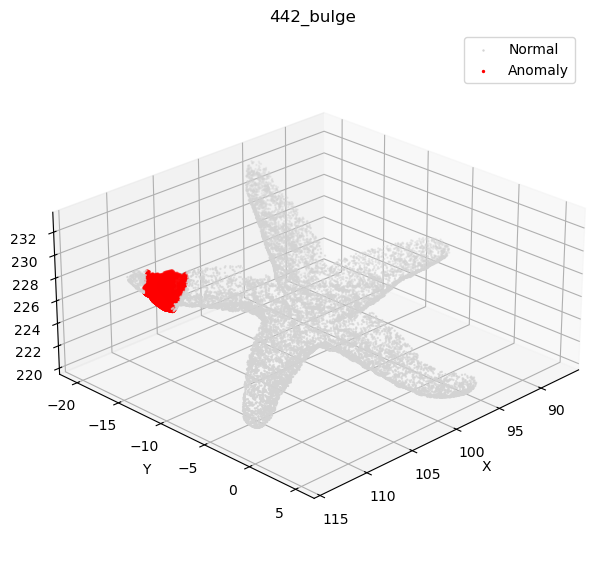

In [ ]:
normal_idx = np.flatnonzero(labels == 0)
anomaly_idx = np.flatnonzero(labels > 0)

rng = np.random.default_rng(42)
normal_idx = rng.choice(
    normal_idx, min(15_000, len(normal_idx)), replace=False
)
anomaly_idx = rng.choice(
    anomaly_idx, min(5_000, len(anomaly_idx)), replace=False
)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

for idx, color, name, size in [
    (normal_idx, "lightgray", "Normal", 0.5),
    (anomaly_idx, "red", "Anomaly", 2),
]:
    p = anomaly_points[idx]
    ax.scatter(p[:, 0], p[:, 1], p[:, 2], c=color, s=size, label=name)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title(gt_path.stem)
ax.set_box_aspect(np.maximum(np.ptp(anomaly_points, axis=0), 1e-6))
ax.view_init(elev=25, azim=45)
ax.legend()

plt.show()